In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('food_delivery_orders.csv', parse_dates=['order_date'])
df.head()

,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0


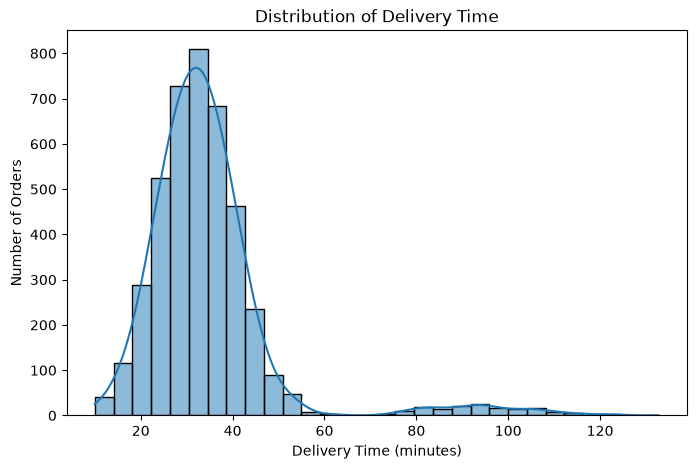

Skewness: 2.88
Mean: 34.54
Median: 32.5


In [16]:
#task1
plt.figure(figsize=(8,5))

sns.histplot(df['delivery_time_min'], kde=True, bins=30)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')

plt.show()


skew = df['delivery_time_min'].skew()
mean = df['delivery_time_min'].mean()
median = df['delivery_time_min'].median()

print("Skewness:", round(skew, 2))
print("Mean:", round(mean, 2))
print("Median:", round(median, 2))

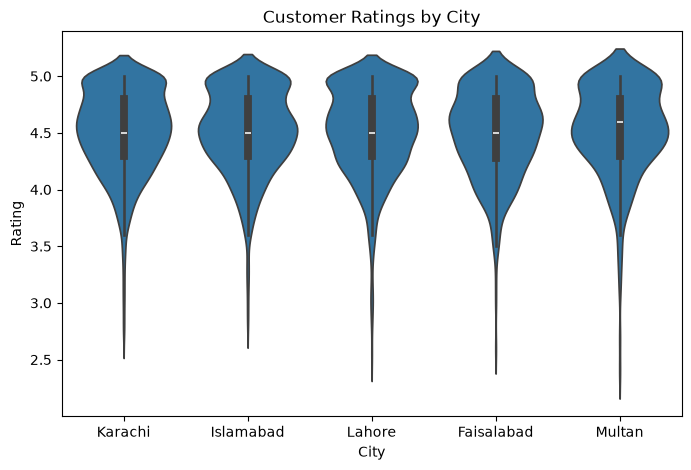

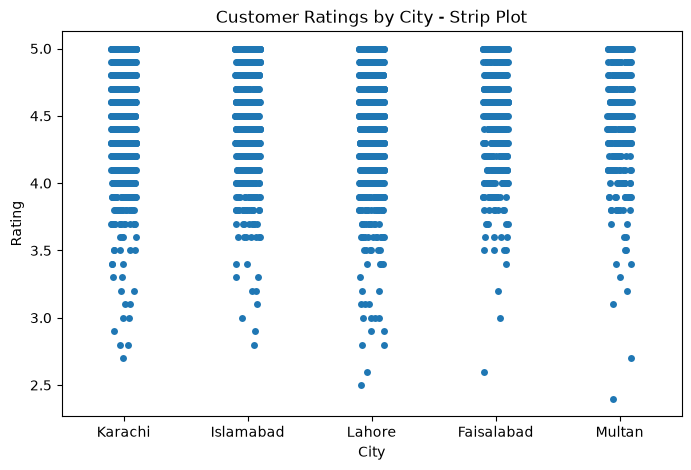

                mean  median       std
city                                  
Faisalabad  4.490041     4.5  0.384213
Islamabad   4.512216     4.5  0.373966
Karachi     4.508255     4.5  0.380484
Lahore      4.511027     4.5  0.396755
Multan      4.520984     4.6  0.400584


In [17]:
#Task 2
plt.figure(figsize=(8,5))

sns.violinplot(data=df, x='city', y='rating')

plt.title('Customer Ratings by City')
plt.xlabel('City')
plt.ylabel('Rating')

plt.show()


plt.figure(figsize=(8,5))

sns.stripplot(
    data=df,
    x='city',
    y='rating',
    jitter=True
)

plt.title('Customer Ratings by City - Strip Plot')
plt.xlabel('City')
plt.ylabel('Rating')

plt.show()


print(df.groupby('city')['rating'].agg(['mean', 'median', 'std']))

Interpretation: Multan has the highest standard deviation (≈0.40) among the five cities and its violin/strip plot shows the widest spread of ratings, even though its mean rating (4.52) is not the lowest. This means Multan customers have the most inconsistent delivery experience

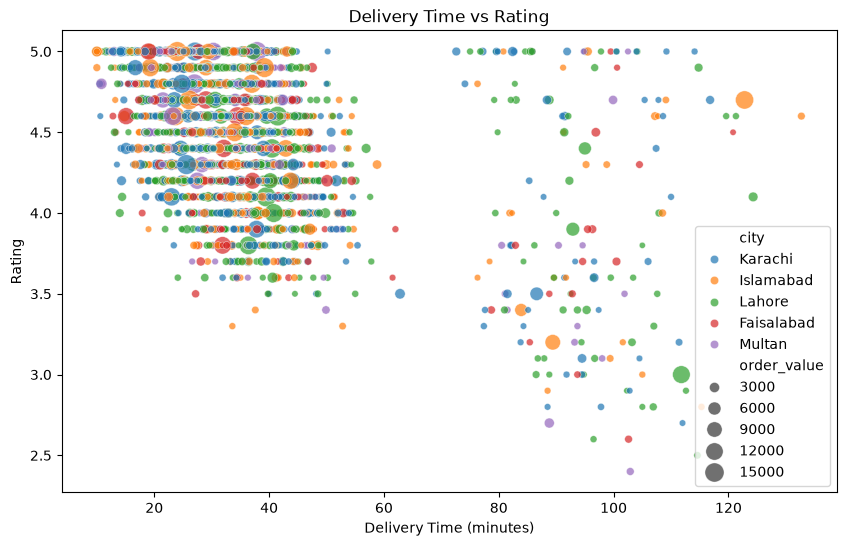

In [29]:
#task 3
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='delivery_time_min',
    y='rating',
    hue='city',
    size='order_value',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Delivery Time vs Rating')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Rating')

plt.show()

Pearson Correlation Matrix:
                   order_value  discount_percent  delivery_time_min  rating  \
order_value               1.00             -0.01               0.00    0.00   
discount_percent         -0.01              1.00               0.01   -0.01   
delivery_time_min         0.00              0.01               1.00   -0.45   
rating                    0.00             -0.01              -0.45    1.00   
profit_per_order         -0.66             -0.08              -0.03    0.01   

                   profit_per_order  
order_value                   -0.66  
discount_percent              -0.08  
delivery_time_min             -0.03  
rating                         0.01  
profit_per_order               1.00  

Spearman Correlation Matrix:
                   order_value  discount_percent  delivery_time_min  rating  \
order_value               1.00              0.01              -0.02    0.00   
discount_percent          0.01              1.00               0.02   -0.00   
de

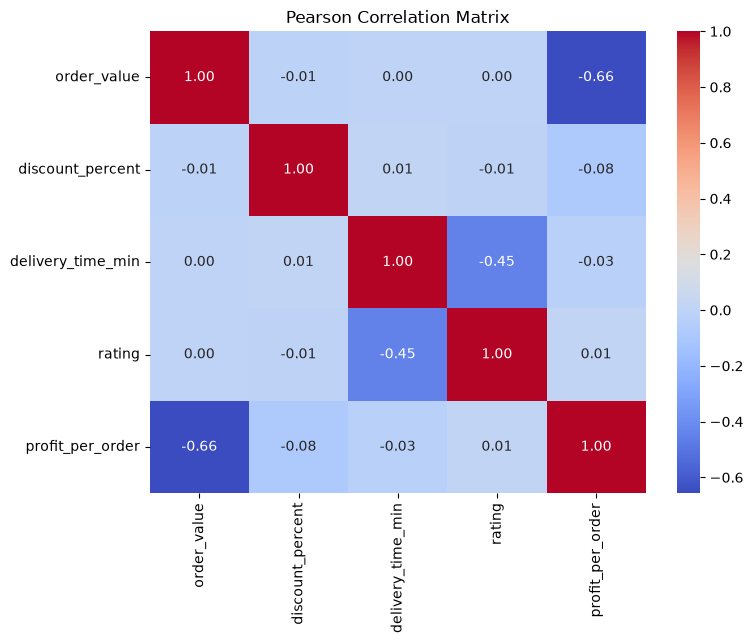

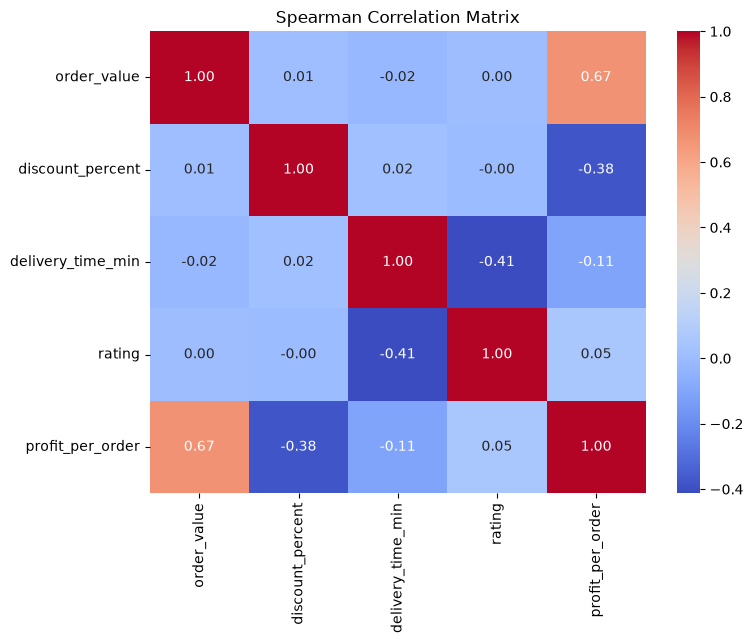

In [31]:
#task 4
numeric_df = df.select_dtypes(include='number')

# Pearson correlation
pearson_corr = numeric_df.corr(method='pearson')

print("Pearson Correlation Matrix:")
print(pearson_corr.round(2))


# Spearman correlation
spearman_corr = numeric_df.corr(method='spearman')

print("\nSpearman Correlation Matrix:")
print(spearman_corr.round(2))

# Compare Pearson and Spearman
difference = abs(pearson_corr - spearman_corr)

difference = difference.where(difference != 0)

print("\nLargest differences:")
print(difference.stack().sort_values(ascending=False).head(10))

# Pearson Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()


# Spearman Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Spearman Correlation Matrix')
plt.show()


Interpretation: Pearson and Spearman show opposite signs for order_value and profit_per_order. This suggests that extreme outliers are strongly affecting the Pearson correlation, while Spearman shows the general positive trend.

Decision: The extreme orders appear genuine, so they should not be removed. Report both correlations and mention that outliers affect Pearson.

Caveat: Correlation does not imply causation.

Average Profit per Order:
restaurant_category   Cafe  Cloud Kitchen  Dessert  Fast Food  Fine Dining  \
city                                                                         
Faisalabad           67.30          65.78   -70.31      20.22       293.70   
Islamabad           -13.50          57.01   -27.88      37.18       153.12   
Karachi             -38.90         136.75    75.24      15.38       302.80   
Lahore               52.35         137.61    65.52      10.62       159.82   
Multan               60.14         -82.78    55.87     -40.78       285.18   
All                  14.65          91.83    31.28      13.61       228.92   

restaurant_category    All  
city                        
Faisalabad           51.89  
Islamabad            35.49  
Karachi              74.10  
Lahore               71.55  
Multan               12.62  
All                  57.37  


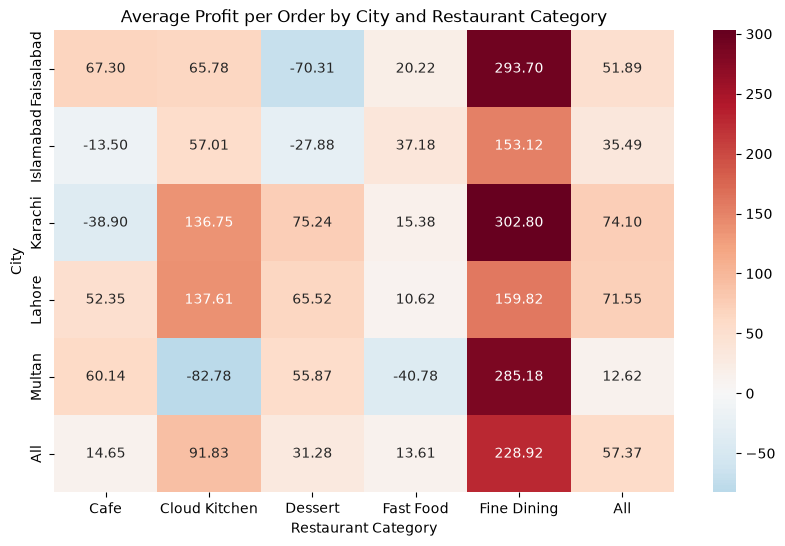


Most Profitable Combination:
City: Karachi
Restaurant Category: Fine Dining
Average Profit per Order: 302.8

Total Revenue by City and Restaurant Category:
restaurant_category       Cafe  Cloud Kitchen    Dessert  Fast Food  \
city                                                                  
Faisalabad            56093.00      205515.67   58415.97  145852.94   
Islamabad            116804.47      342842.35  105370.12  203444.04   
Karachi              205017.31      371410.10   79235.00  288490.38   
Lahore               171131.14      449766.65  101385.00  379476.87   
Multan                51438.00      181931.62   25374.00  100182.58   

restaurant_category  Fine Dining  
city                              
Faisalabad             123173.00  
Islamabad              270610.22  
Karachi                371893.00  
Lahore                 336923.84  
Multan                  81485.00  

Top Revenue Combination:
City: Lahore
Restaurant Category: Cloud Kitchen
Total Revenue: 449766.65



In [27]:
#task 5
pivot = df.pivot_table(
    values='profit_per_order',
    index='city',
    columns='restaurant_category',
    aggfunc='mean',
    margins=True
)

print("Average Profit per Order:")
print(pivot.round(2))


# 2. Create heatmap

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0
)

plt.title('Average Profit per Order by City and Restaurant Category')
plt.xlabel('Restaurant Category')
plt.ylabel('City')

plt.show()


profit_data = pivot.drop(index='All').drop(columns='All')

#maximum profit
city, category = profit_data.stack().idxmax()
max_profit = profit_data.loc[city, category]

print("\nMost Profitable Combination:")
print("City:", city)
print("Restaurant Category:", category)
print("Average Profit per Order:", round(max_profit, 2))

revenue_pivot = df.pivot_table(
    values='order_value',
    index='city',
    columns='restaurant_category',
    aggfunc='sum'
)

print("\nTotal Revenue by City and Restaurant Category:")
print(revenue_pivot.round(2))


revenue_city, revenue_category = revenue_pivot.stack().idxmax()
max_revenue = revenue_pivot.loc[revenue_city, revenue_category]

print("\nTop Revenue Combination:")
print("City:", revenue_city)
print("Restaurant Category:", revenue_category)
print("Total Revenue:", round(max_revenue, 2))


print("\nComparison:")

if city == revenue_city and category == revenue_category:
    print("The most profitable combination is also the top revenue generator.")
else:
    print("The most profitable combination is different from the top revenue generator.")

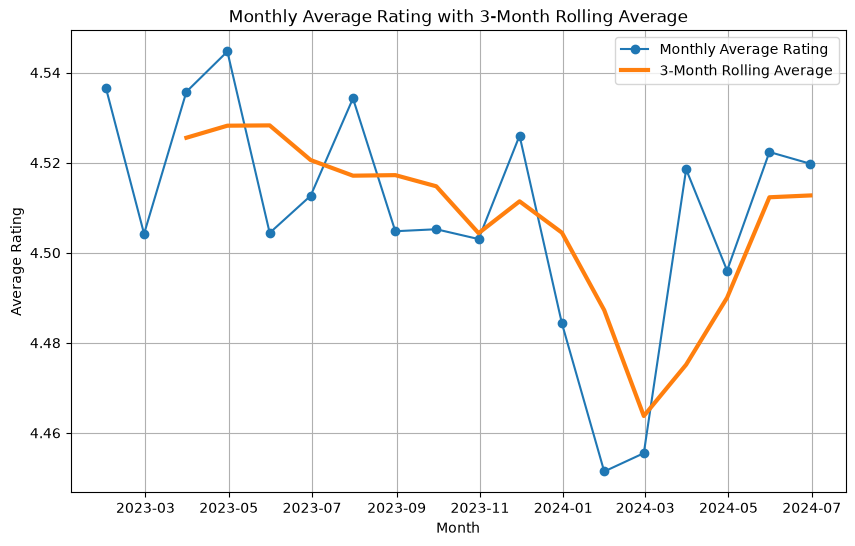

In [21]:
#task 6

df['order_date'] = pd.to_datetime(df['order_date'])
df = df.set_index('order_date')

monthly_rating = df['rating'].resample('ME').mean()

rolling_rating = monthly_rating.rolling(window=3).mean()

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_rating,
    marker='o',
    label='Monthly Average Rating'
)

plt.plot(
    rolling_rating,
    linewidth=3,
    label='3-Month Rolling Average'
)

plt.title('Monthly Average Rating with 3-Month Rolling Average')
plt.xlabel('Month')
plt.ylabel('Average Rating')

plt.legend()
plt.grid(True)

plt.show()

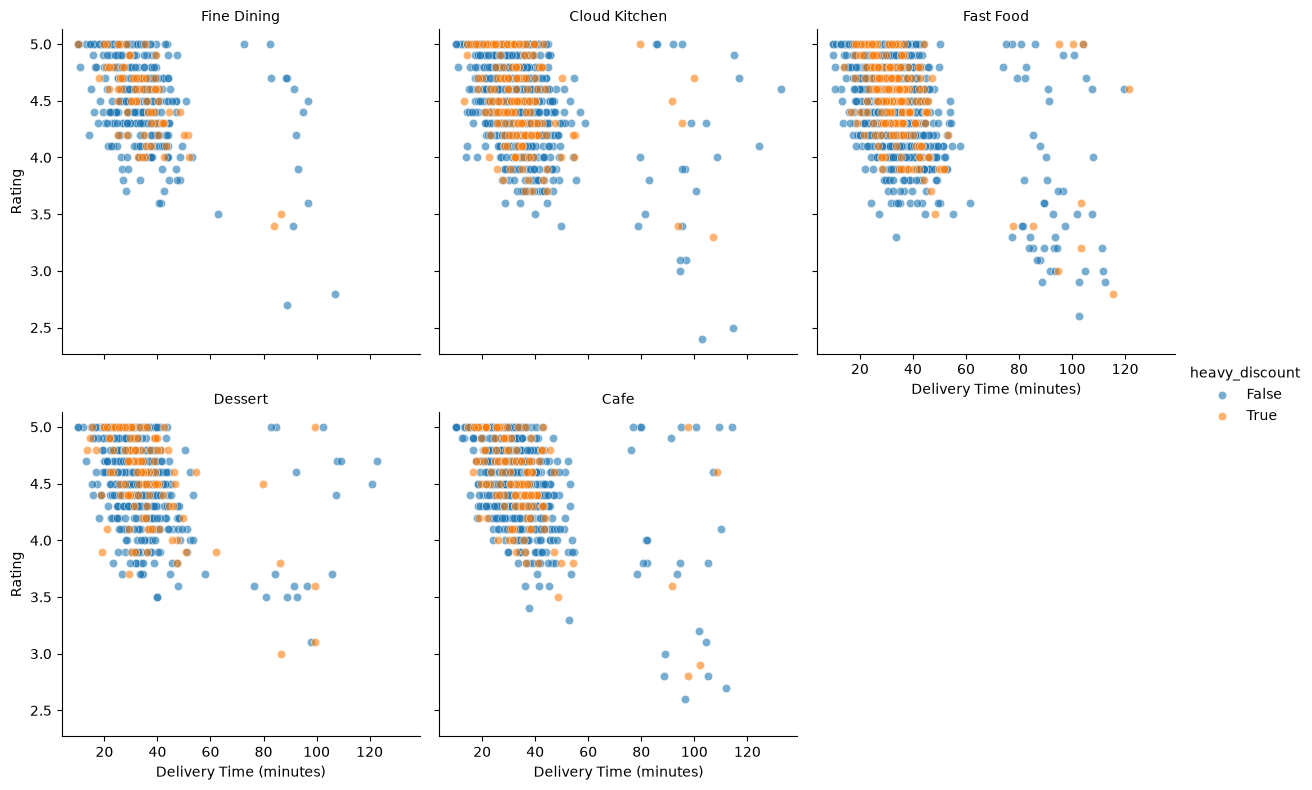

In [22]:
#task 7

df['heavy_discount'] = df['discount_percent'] > 20


g = sns.FacetGrid(
    df,
    col='restaurant_category',
    hue='heavy_discount',
    height=4,
    col_wrap=3
)

g.map(
    sns.scatterplot,
    'delivery_time_min',
    'rating',
    alpha=0.6
)

g.add_legend()

g.set_axis_labels(
    'Delivery Time (minutes)',
    'Rating'
)

g.set_titles(
    '{col_name}'
)

plt.show()

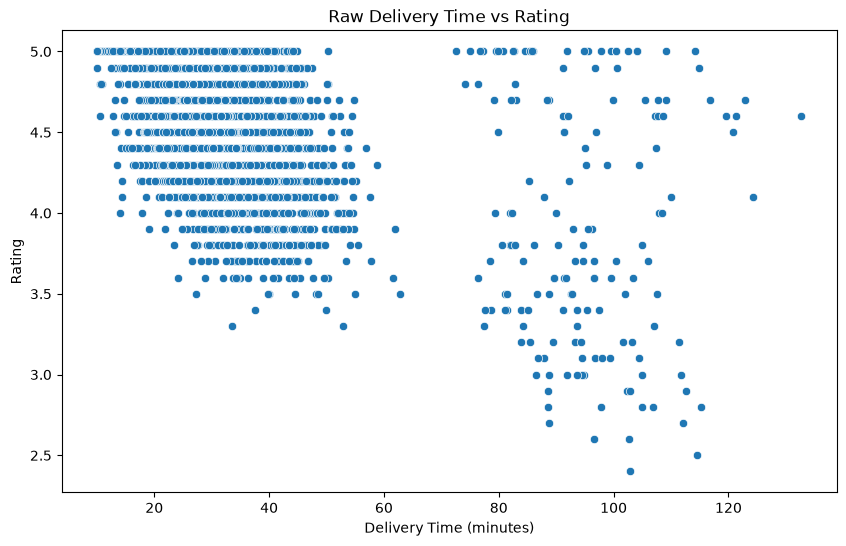

Best rating despite long delivery:
order_date             2024-04-30
city                      Karachi
restaurant_category          Cafe
cuisine                    Bakery
order_value                 507.0
discount_percent             17.7
delivery_time_min           114.1
rating                        5.0
profit_per_order           -116.0
Name: 3723, dtype: object

Worst rating despite fast delivery:
order_date                2023-01-14
city                          Multan
restaurant_category    Cloud Kitchen
cuisine                       Indian
order_value                   1197.0
discount_percent                 1.8
delivery_time_min              102.9
rating                           2.4
profit_per_order               171.0
Name: 101, dtype: object


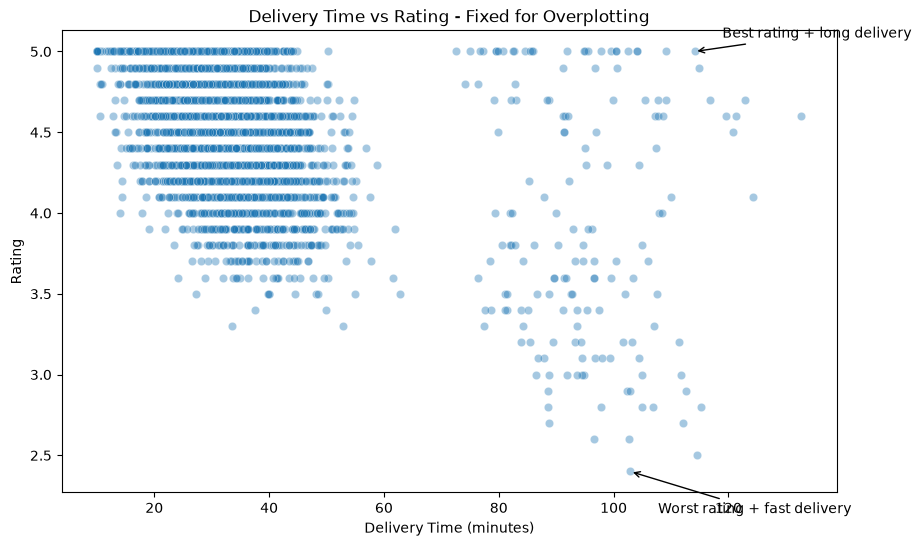

In [23]:
#task 8

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='delivery_time_min',
    y='rating'
)

plt.title('Raw Delivery Time vs Rating')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Rating')
plt.show()

best_rating = df['rating'].max()

best_long = df[
    df['rating'] == best_rating
].sort_values(
    'delivery_time_min',
    ascending=False
).iloc[0]


# Worst rating despite fast delivery
worst_rating = df['rating'].min()

worst_fast = df[
    df['rating'] == worst_rating
].sort_values(
    'delivery_time_min',
    ascending=True
).iloc[0]


print("Best rating despite long delivery:")
print(best_long)

print("\nWorst rating despite fast delivery:")
print(worst_fast)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='delivery_time_min',
    y='rating',
    alpha=0.4
)

plt.annotate(
    'Best rating + long delivery',
    xy=(
        best_long['delivery_time_min'],
        best_long['rating']
    ),
    xytext=(20, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.annotate(
    'Worst rating + fast delivery',
    xy=(
        worst_fast['delivery_time_min'],
        worst_fast['rating']
    ),
    xytext=(20, -30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)


plt.title('Delivery Time vs Rating - Fixed for Overplotting')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Rating')

plt.show()

I used alpha transparency because repeated rating values cause points to overlap, and transparency makes the density of overlapping observations easier to see.